# Action potential waveforms are state-dependent
### Finding 1 of 5

Martin-Burgos, B., Juavinett, A., Riviere, P., Hammonds, R., & Voytek, B. (2026). *Action potential waveforms are state-dependent*. bioRxiv. https://www.biorxiv.org/content/10.64898/2026.09.15.751814v1

For over a century, neuroscience has treated the action potential as a binary, all-or-none event, every spike functionally identical to the next. This paper asks whether that abstraction throws away real information. It turns out the shape of a single spike, not just whether or when it fired, varies with the input driving the neuron, varies more from spike to spike within one neuron than expected, and tracks the surrounding network state.

This notebook walks through one of the paper's five findings. See the [repo README](README.md) for the full picture and the other four notebooks.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import sys, os, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

AP1 = 'AP_empirical_paper_all_analyses'
sys.path.append(f'{AP1}/datasets/shared_helper_modules/')
from spikewise_plotting import plot_corr_heatmap_only_spk
from spikewise.patch.fit import Spike

## Parameterization captures intra-spike correlations

**Finding:** a spike's early shape (how it ramps up and where it bends before the peak) is tied to its later shape (how sharp the peak is and how fast it decays afterward).

We describe every spike with a small set of interpretable numbers rather than a black-box embedding: ramp amplitude, the timing and size of the small bend before the peak, peak amplitude/width/sharpness, and the repolarization (decay) rate afterward. If these numbers capture something real about spike physiology, they should correlate with each other in structured ways within a single neuron. That holds up: across every neuron and both datasets, peak sharpness, peak width, and the timing of the pre-peak bend consistently track one another, with spikes that bend earlier turning out wider and less sharp. Below, in one interneuron (pvc-6 Cell 1), the decay rate also strongly tracks peak shape, and faster decay is followed by a shorter gap before the next spike.

**Figure:** correlation matrix across all pairs of spike features, one neuron (this is the exact code and cell used for the paper's Fig. 2D).

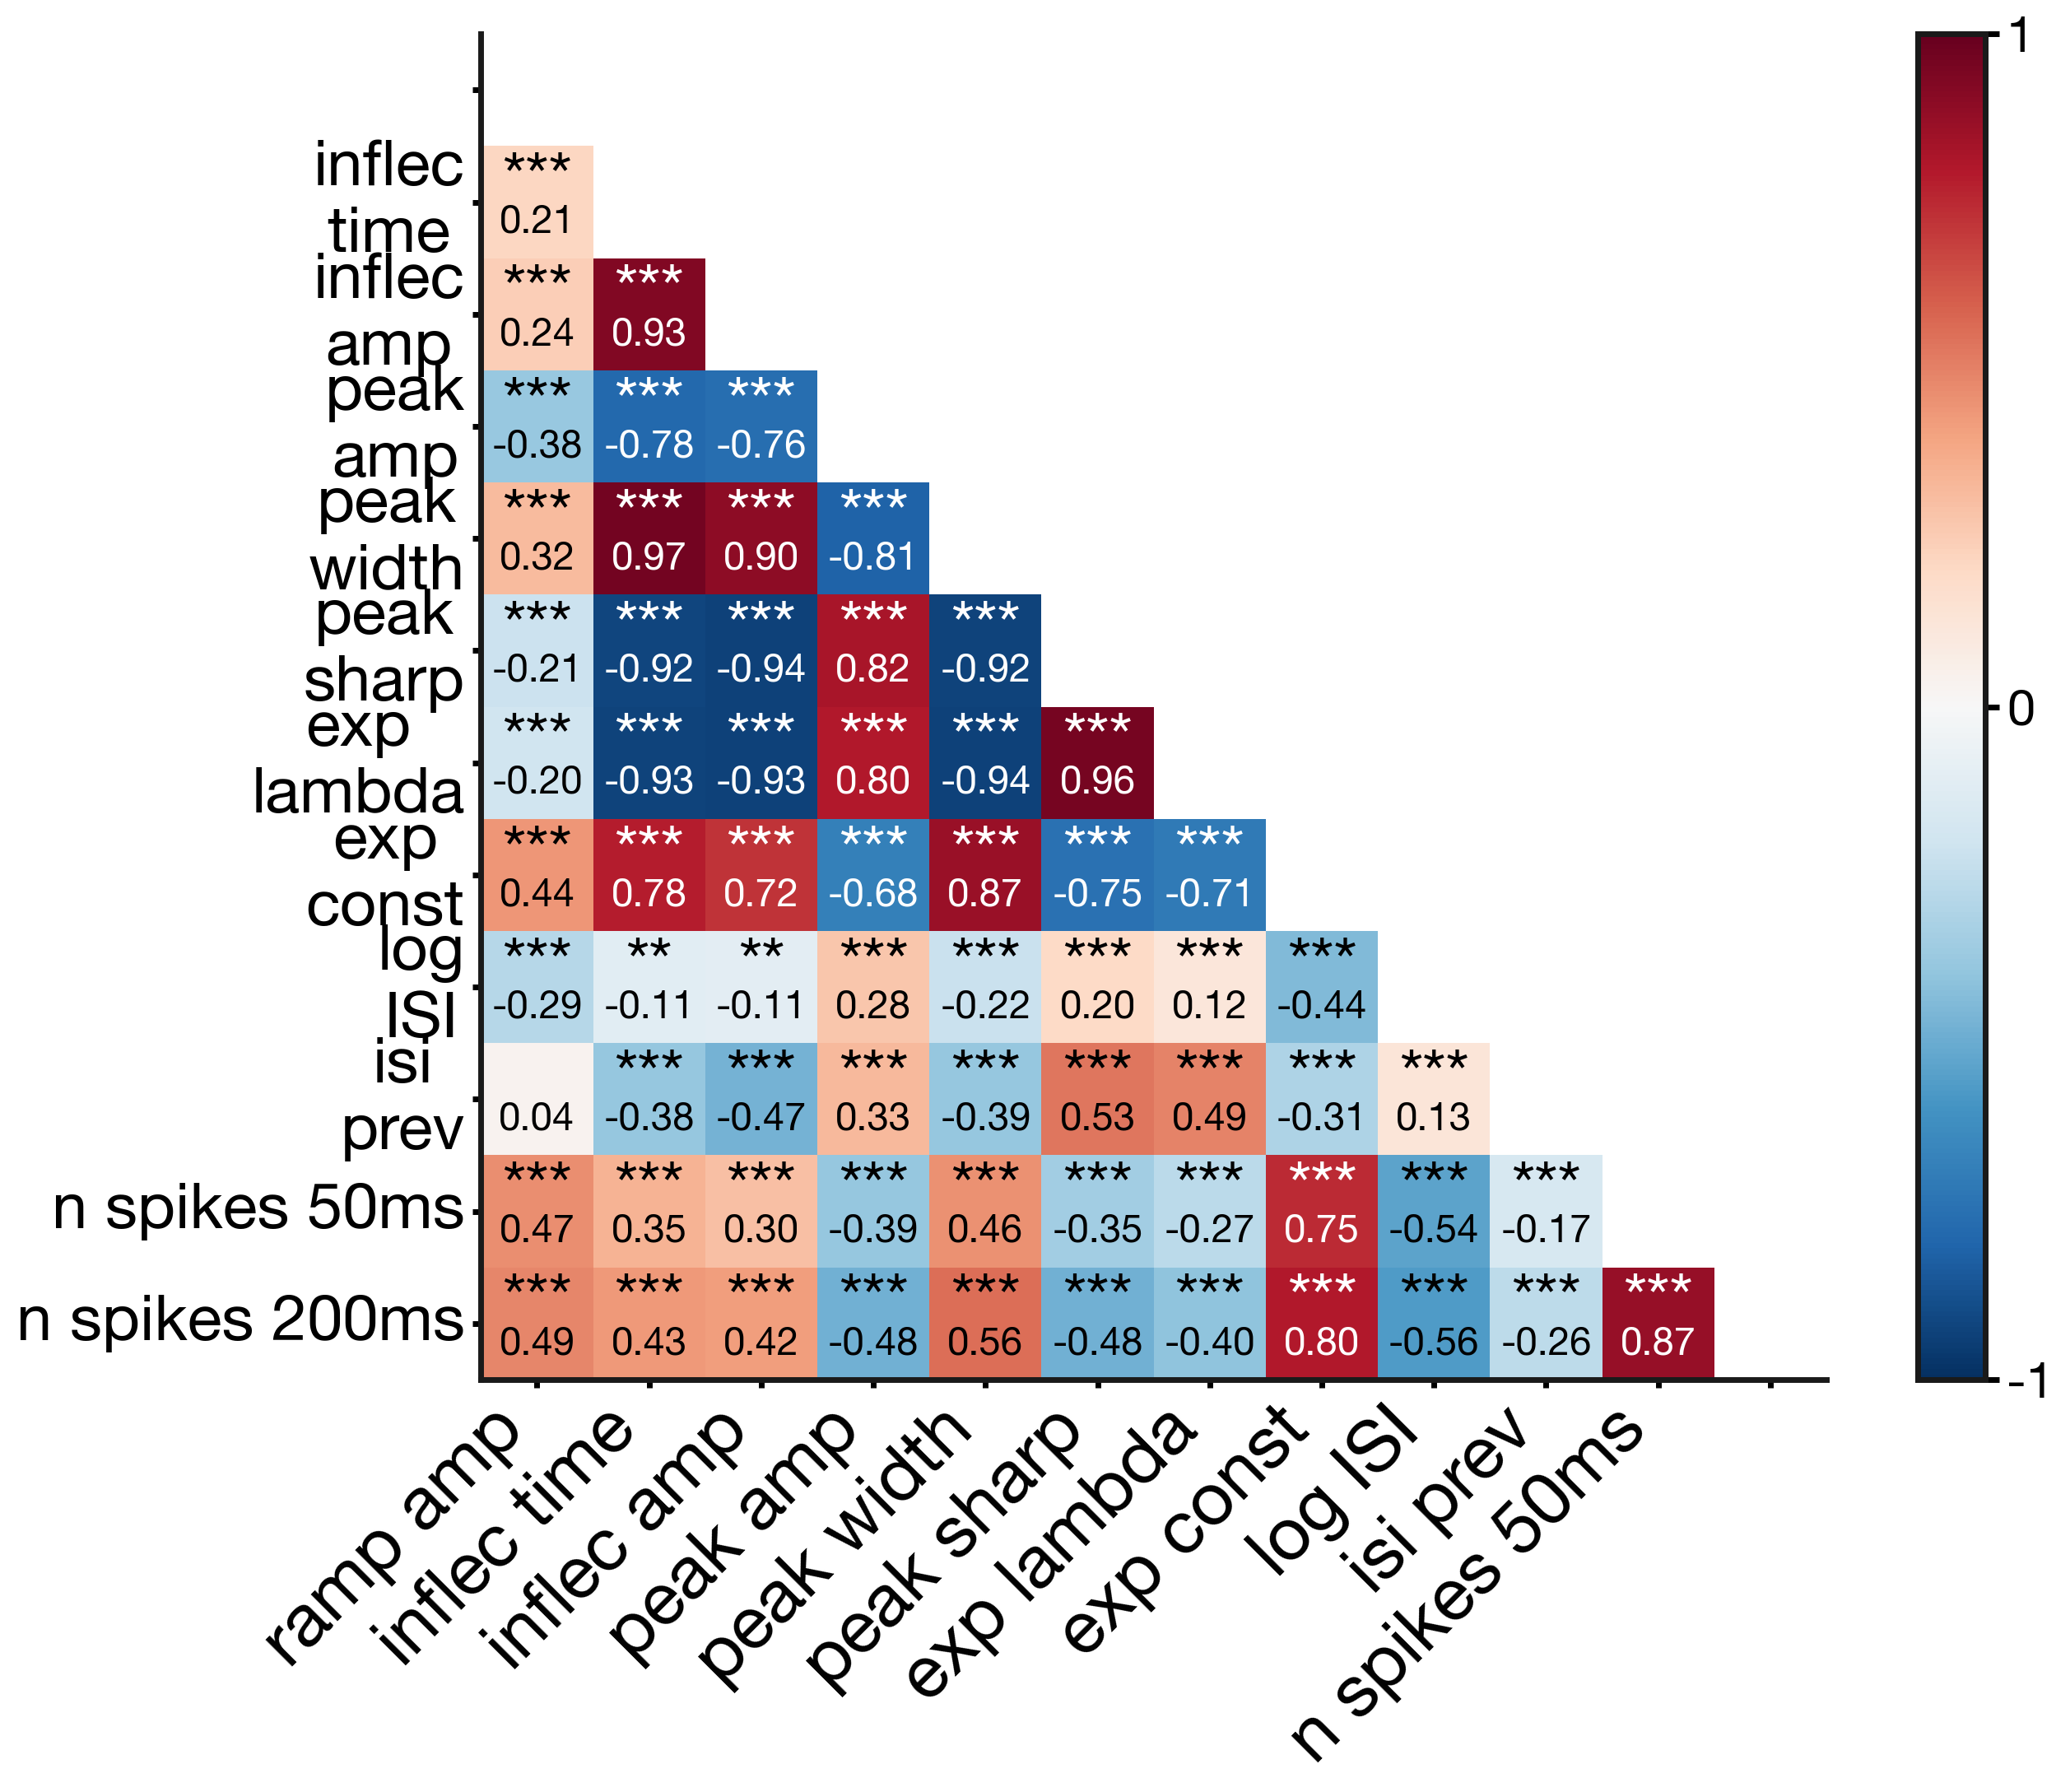

In [2]:
# Same code as paper_aux_figs/algorithm/AP_empirical_algorithm_sch.ipynb (Fig 2D cell)
with open('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/pvc6_pickles/all_data.pkl', 'rb') as f:
    _all_data_pvc6 = pickle.load(f)
_all_data_flat_pvc6 = [spike for sweep in _all_data_pvc6 for spike in sweep]

_sp_pvc6 = Spike(thresh_amp=-10, window_length=(5., 5.), smooth_frac=.008, pre_inflection_ms=0.5)
_sp_pvc6.fit(_all_data_flat_pvc6, 200000, n_jobs=-1)
_df_pvc6 = _sp_pvc6.df_features.copy()
_df_pvc6['original_index'] = _df_pvc6.index

# Ensure inflection times are between 0 and 2 ms
_df_pvc6 = _df_pvc6.loc[_df_pvc6['inflection_time'] > 0.]
_df_pvc6 = _df_pvc6.loc[_df_pvc6['inflection_time'] < 2.]
# Remove low r-squares (ramping fits are especially noisy)
_df_pvc6 = _df_pvc6.loc[_df_pvc6['r_squared_exp']  >= .5]
_df_pvc6 = _df_pvc6.loc[_df_pvc6['r_squared_ramp'] >= .1]
# log10 ISIs
_df_pvc6[['isi']] = np.log10(_df_pvc6[['isi']])
_df_pvc6.rename(columns={'isi': 'log_isi'}, inplace=True)
_df_pvc6 = _df_pvc6.drop(['r_squared_exp', 'r_squared_ramp'], axis=1)
_df_pvc6 = _df_pvc6.replace([np.inf, -np.inf], np.nan)

spike_features = [c for c in _df_pvc6.columns if c != 'original_index']
plot_corr_heatmap_only_spk(_df_pvc6, spike_features)